<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/blob/main/Copy_of_Ademola_EKF_UKF333.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [328]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.integrate import odeint
import scipy.optimize

import sympy as sp

import pandas as pd

from scipy.integrate import odeint
import copy

In [329]:

try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

In [330]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

tb_simulations = import_local_or_github('tb_simulations', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
extended_kalman_filter = import_local_or_github('extended_kalman_filter', directory='../Utility')
unscented_kalman_filter = import_local_or_github('unscented_kalman_filter', directory='../Utility')

$$
\mathbf{\dot{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) = \mathbf{f_0}(\mathbf{x}) + \mathbf{f_1}(\mathbf{x})\bbox[lightgreen]{\alpha} + \mathbf{f_2}(\mathbf{x})\bbox[lightgreen]{\kappa}
$$

$$
\frac{d}{dt}
\begin{bmatrix}
\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{V} \\[0.3em]
\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{R} \\[0.3em]
\bbox[pink]{\beta} \\[0.3em]
\bbox[pink]{\sigma}
\end{bmatrix} =
\overset{f_0}{\begin{bmatrix}
\bbox[lightblue]{\Lambda} - \bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[lightblue]{\mu}\bbox[yellow]{S} \\[0.3em]
0 - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\mu}\bbox[yellow]{V} \\[0.3em]
\bbox[pink]{\beta}\bbox[yellow]{SI} + \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{I} \\[0.3em]
\bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{R}\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} +
\overset{f_1}{\begin{bmatrix}
-\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{S} \\[0.3em]
0 \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\alpha} +
\overset{f_2}{\begin{bmatrix}
\bbox[pink]{\beta}\bbox[yellow]{SI} \\[0.3em]
\bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
-\bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\kappa}
$$

# Dynamics and measurement functions

In [331]:
# all three measurement functions can be accessed from the planar drone script:
h_a = tb_simulations.H('h_ivr').h
h_b = tb_simulations.H('h_all_svir').h
h_c = tb_simulations.H('h_comprehensive').h


In [332]:
f = tb_simulations.F().f
h = h_a # choose one of the measurement functions

In [333]:
h(None, None, return_measurement_names=True)

['I_absolute', 'V_absolute', 'R_absolute']

In [334]:
def u_func(x_vec, t):
    """Simple vaccination and social distancing controller"""
    I = x_vec[2]
    I_threshold = 0.005
    alpha = 0.01 if I > I_threshold else 0.005
    kappa = 0.3 if I > I_threshold else 0.1
    return np.array([alpha, kappa])

In [335]:
def f_ode(x_vec, t):
    """Wrapper for odeint"""
    u_vec = u_func(x_vec, t)
    return f(x_vec, u_vec)


In [336]:
N = 223000000

# TRUE initial conditions (generates real data)
x0_true = np.array([
    52309000/N,      # S: 0.2345 (23.45%)
    158330000/N,     # V: 0.7100 (71.00%)
    361000/N,        # I: 0.0016 (0.16%)
    12000000/N,      # R: 0.0538 (5.38%)
    0.00003,         # beta: realistic TB transmission
    0.85             # sigma: 85% vaccine efficacy
])

# FILTER INITIAL GUESS (wrong but reasonable)
x0_filter = np.array([
    60000000/N,      # S: 0.269 (15% error)
    145000000/N,     # V: 0.650 (8% error)
    500000/N,        # I: 0.0022 (38% error)
    17500000/N,      # R: 0.078 (46% error)
    0.00005,         # beta: 67% error
    0.70             # sigma: 18% error
])

# Run simulation

In [337]:
t_sim = np.arange(0, 365, 1.0)
result = odeint(f_ode, x0_true, t_sim)


In [338]:
x_sim = {
    'S': result[:, 0],
    'V': result[:, 1],
    'I': result[:, 2],
    'R': result[:, 3],
    'beta': result[:, 4],
    'sigma': result[:, 5]
}

In [339]:
u_sim = {'alpha': [], 'kappa': []}
for i in range(len(t_sim)):
    u = u_func(result[i], t_sim[i])
    u_sim['alpha'].append(u[0])
    u_sim['kappa'].append(u[1])

In [340]:
REPORTING_RATE = 0.60

In [341]:
y_true_absolute = {
    'S_absolute': x_sim['S'] * N,
    'V_absolute': x_sim['V'] * N,
    'I_absolute': x_sim['I'] * N,
    'R_absolute': x_sim['R'] * N
}


# Simulate noisy measurements

In [342]:
measurement_noise_stds = {
    'V_absolute': 2000000.0,   # ±2M (vaccination records)
    'I_absolute': 15000.0,     # ±15K (reported cases)
    'R_absolute': 500000.0     # ±500K (treatment records)
}


In [343]:
np.random.seed(42)
y_noisy_absolute = {}
y_noisy_absolute['S_absolute'] = np.full(len(t_sim), np.nan)

In [362]:
y_noisy_absolute['V_absolute'] = (
    y_true_absolute['V_absolute'] +
    np.random.normal(0, measurement_noise_stds['V_absolute'], len(t_sim))
)

y_noisy_absolute['I_absolute'] = np.maximum(
    y_true_absolute['I_absolute'] * REPORTING_RATE +
    np.random.normal(0, measurement_noise_stds['I_absolute'], len(t_sim)),
    0
)

y_noisy_absolute['R_absolute'] = (
    y_true_absolute['R_absolute'] +
    np.random.normal(0, measurement_noise_stds['R_absolute'], len(t_sim))
)


In [363]:
y_noisy = {key: y_noisy_absolute[key] / N for key in y_noisy_absolute.keys()}

<Axes: xlabel='Time', ylabel='R_absolute'>

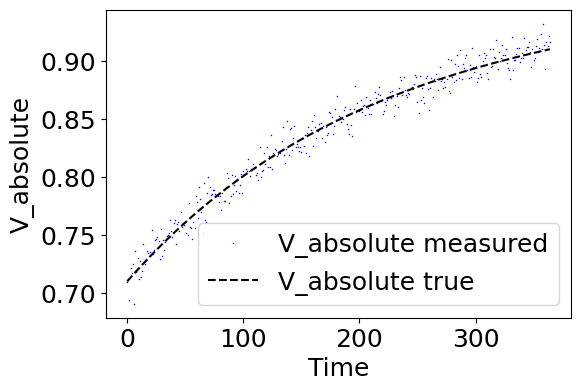

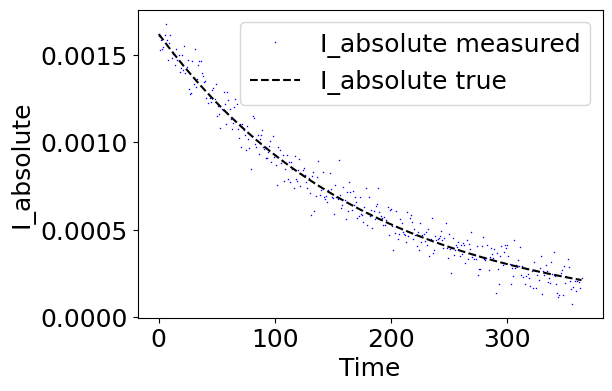

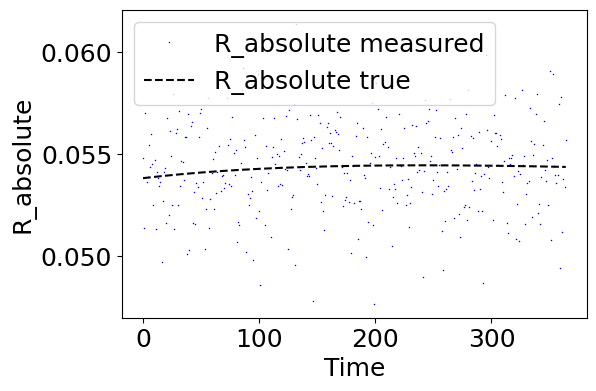

In [364]:
plot_tme(t_sim, x_sim['V'], y_noisy['V_absolute'], label_var='V_absolute')
plot_tme(t_sim, x_sim['I'], y_noisy['I_absolute'], label_var='I_absolute')
plot_tme(t_sim, x_sim['R'], y_noisy['R_absolute'], label_var='R_absolute')

In [347]:
def h_partial(x_vec, u_vec, return_measurement_names=False):
    """
    Partial observation: Only V, I (60% reported), R
    S is HIDDEN
    """
    if return_measurement_names:
        return ['V_absolute', 'I_reported', 'R_absolute']

    V = x_vec[1]
    I = x_vec[2]
    R = x_vec[3]

    # Model includes underreporting in measurement
    y_vec = np.array([
        V * N,
        I * N * REPORTING_RATE,  # 60% reporting built into model
        R * N
    ])

    return y_vec

### Save data as dataframes

In [348]:
y_noisy_df = pd.DataFrame({
    'V_absolute': y_noisy['V_absolute'],
    'I_reported': y_noisy['I_absolute'],  # This is already underreported
    'R_absolute': y_noisy['R_absolute']
})
u_sim_df = pd.DataFrame(u_sim)
u0 = np.array([u_sim['alpha'][0], u_sim['kappa'][0]])

# Kalman filter parameters and initilization

In [349]:
P0 = np.diag([
    0.01,      # S: moderate uncertainty
    0.01,      # V: moderate uncertainty
    0.002,     # I: higher uncertainty
    0.02,      # R: higher uncertainty
    0.00001,   # beta: high uncertainty
    0.05       # sigma: high uncertainty
])

Q = np.diag([
    1e-6,   # S
    1e-6,   # V
    1e-7,   # I
    1e-6,   # R
    1e-10,  # beta (slow-varying parameter)
    1e-10   # sigma (slow-varying parameter)
])

R_stds = np.array([
    measurement_noise_stds['V_absolute'] / N,
    measurement_noise_stds['I_absolute'] / N,
    measurement_noise_stds['R_absolute'] / N
])
R = np.diag(R_stds**2)

# Extended Kalman Filter

In [350]:
EKF = extended_kalman_filter.EKF(
    f, h, x0_filter, u0, P0, Q, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    circular_measurements=(0, 0, 0)  # 3 measurements
)

In [351]:
EKF.estimate(y_noisy_df, u_sim_df)

In [352]:
EKF.history.keys()

dict_keys(['X', 'U', 'Z', 'P', 'P_diags', 'R', 'Q', 'F', 'H', 'S', 'K', 'E', 'rho', 'Jk', 'inv_Jk'])

In [353]:
# State estimate
x_est = pd.DataFrame(np.vstack(EKF.history['X']), columns=f(None,None,return_state_names=True))

In [354]:
# Covariance diagonals
P_diags = np.vstack([np.diag(EKF.history['P'][i]) for i in range(len(EKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

## Plots

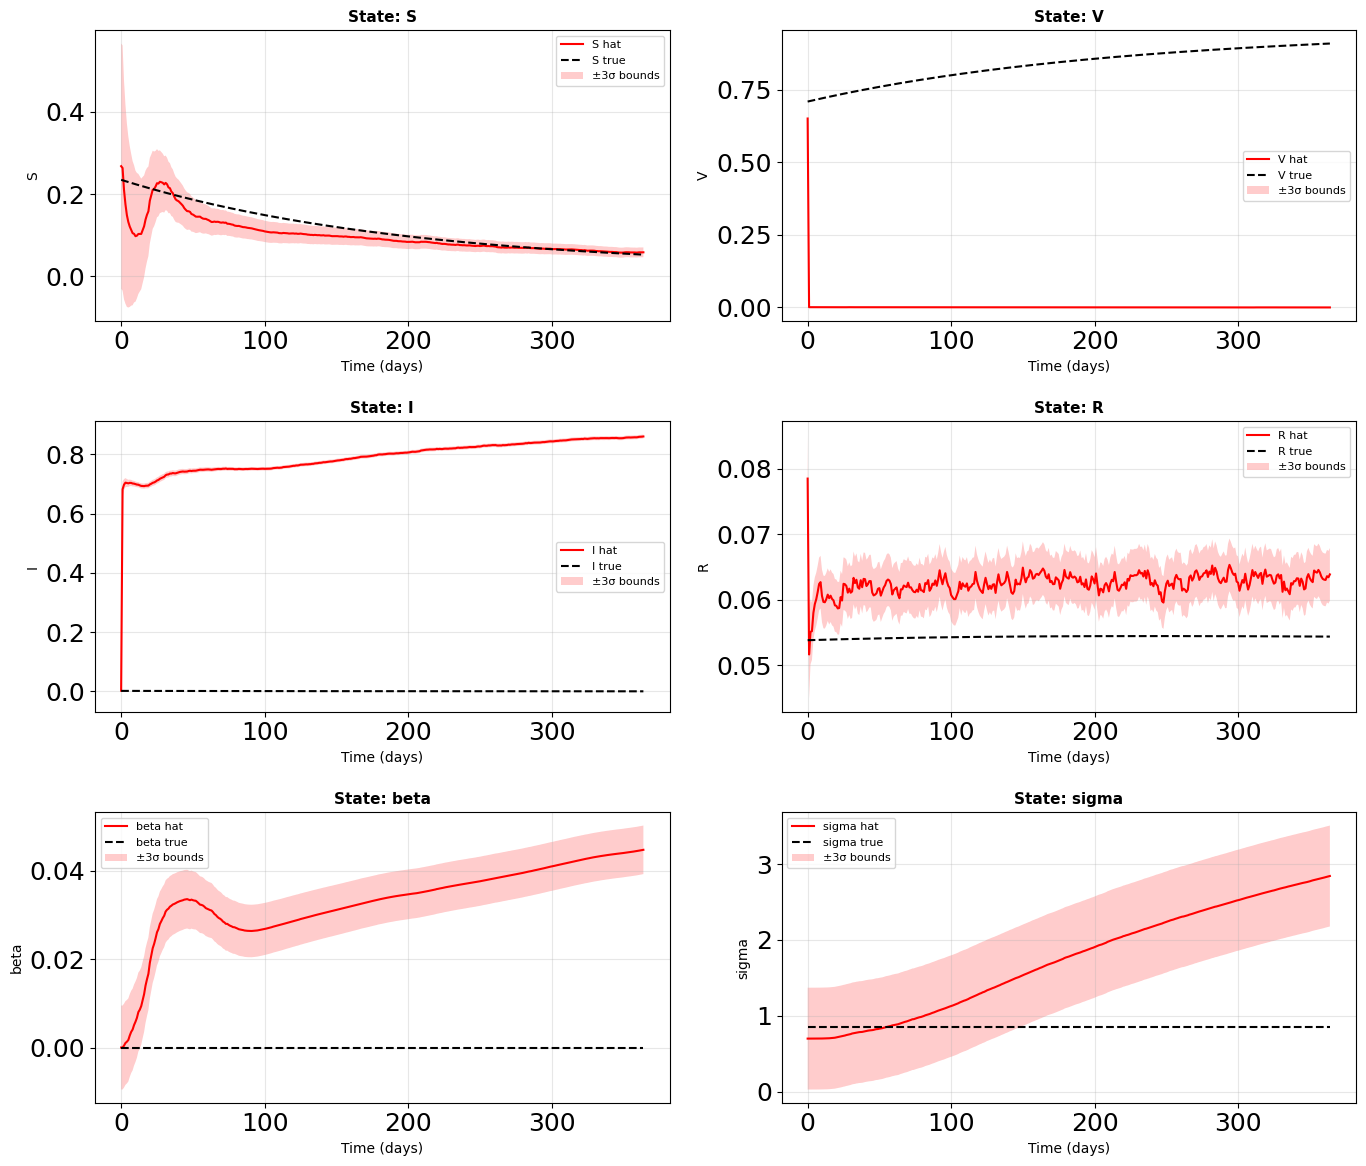

In [355]:
import matplotlib.pyplot as plt
import numpy as np

# Get state names
state_names = f(None, None, return_state_names=True)
n_states = len(state_names)

# Create subplots - 3 rows x 2 columns for 6 states
fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=100)
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Convert to numpy arrays once
x_est_array = np.array(x_est)
P_diags_array = np.array(P_diags)

# Plot each state
for i, state in enumerate(state_names):
    ax = axes[i]

    # Extract columns for this state
    x_est_col = x_est_array[:, i]
    P_diag_col = P_diags_array[:, i]

    # Plot true trajectory, measurements (if available), and estimate
    if state in y_noisy.keys():
        # If we have measurements for this state
        plot_tme(t_sim, x_sim[state], y_noisy[state], x_est_col,
                label_var=state, ax=ax)
    else:
        # No measurements for this state (e.g., beta, sigma)
        plot_tme(t_sim, x_sim[state], None, x_est_col,
                label_var=state, ax=ax)

    # Add 3-sigma uncertainty bounds
    plus_3sigma = x_est_col + 3*np.sqrt(P_diag_col)
    minus_3sigma = x_est_col - 3*np.sqrt(P_diag_col)
    ax.fill_between(t_sim, plus_3sigma, minus_3sigma,
                    facecolor='red', edgecolor='none', alpha=0.2,
                    label='±3σ bounds')

    # Formatting
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel(f'{state}', fontsize=10)
    ax.set_title(f'State: {state}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# Unscented Kalman Filter

In [356]:
UKF = unscented_kalman_filter.UKF(
    f, h_partial, x0_filter, u0, P0, Q, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    alpha=0.1
)

In [357]:
UKF.estimate(y_noisy_df, u_sim_df)

/content/unscented_kalman_filter.py:439: RuntimeWarning: invalid value encountered in sqrt
  r = np.sqrt(R[i,i]**2 + sign * x[i]**2)
/content/unscented_kalman_filter.py:444: RuntimeWarning: divide by zero encountered in divide
  R[i, i+1:] = (R[i, i+1:] + sign * s * x[i+1:]) / c
/content/unscented_kalman_filter.py:441: RuntimeWarning: divide by zero encountered in scalar divide
  s = x[i] / R[i,i]
/content/unscented_kalman_filter.py:444: RuntimeWarning: invalid value encountered in add
  R[i, i+1:] = (R[i, i+1:] + sign * s * x[i+1:]) / c


In [358]:
UKF.history.keys()

dict_keys(['X', 'P', 'P_diags', 'sigma_points'])

In [359]:
# State estimate
x_est = pd.DataFrame(np.vstack(UKF.history['X']), columns=f(None,None,return_state_names=True))

In [360]:
# Covariance diagonals
P_diags = np.vstack([np.diag(UKF.history['P'][i]) for i in range(len(UKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

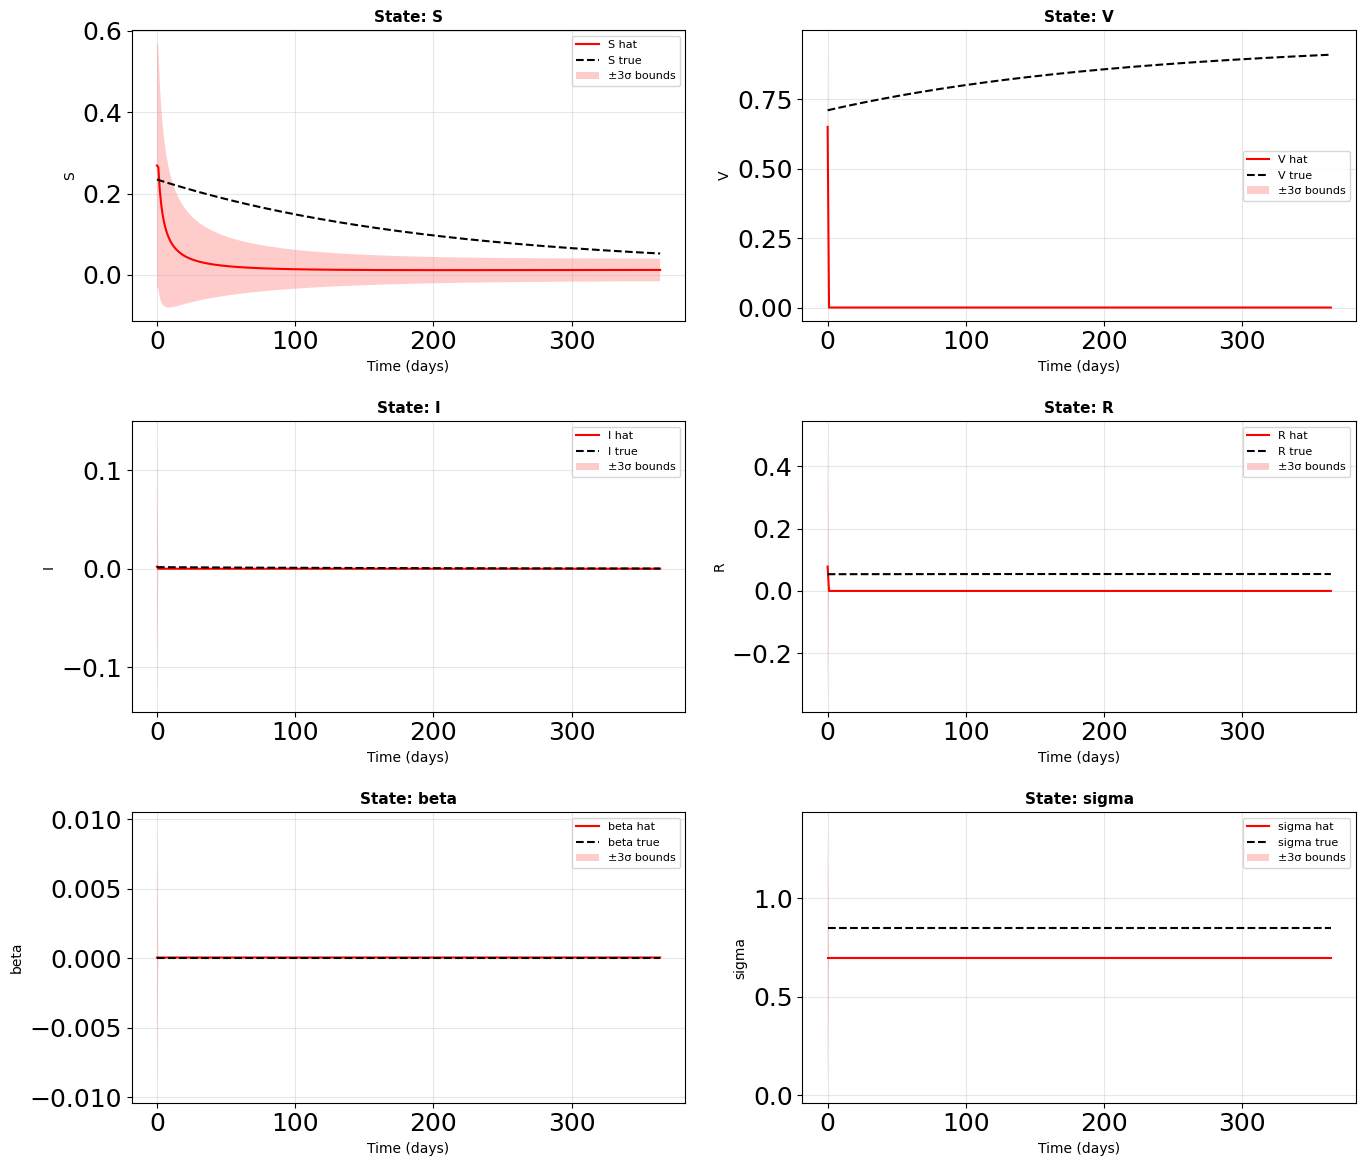

In [361]:
import matplotlib.pyplot as plt
import numpy as np

# Get state names
state_names = f(None, None, return_state_names=True)
n_states = len(state_names)

# Create subplots - 3 rows x 2 columns for 6 states
fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=100)
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Convert to numpy arrays once
x_est_array = np.array(x_est)
P_diags_array = np.array(P_diags)

# Plot each state
for i, state in enumerate(state_names):
    ax = axes[i]

    # Extract columns for this state
    x_est_col = x_est_array[:, i]
    P_diag_col = P_diags_array[:, i]

    # Plot true trajectory, measurements (if available), and estimate
    if state in y_noisy.keys():
        # If we have measurements for this state
        plot_tme(t_sim, x_sim[state], y_noisy[state], x_est_col,
                label_var=state, ax=ax)
    else:
        # No measurements for this state (e.g., beta, sigma)
        plot_tme(t_sim, x_sim[state], None, x_est_col,
                label_var=state, ax=ax)

    # Add 3-sigma uncertainty bounds
    plus_3sigma = x_est_col + 3*np.sqrt(P_diag_col)
    minus_3sigma = x_est_col - 3*np.sqrt(P_diag_col)
    ax.fill_between(t_sim, plus_3sigma, minus_3sigma,
                    facecolor='red', edgecolor='none', alpha=0.2,
                    label='±3σ bounds')

    # Formatting
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel(f'{state}', fontsize=10)
    ax.set_title(f'State: {state}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
